In [1]:
from collections import defaultdict

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import torch

from score.score import Score1d, TemperedDistributionScore
from score.distributions import (
	BrownianDiffusionGaussianMixture,
	symmetric_gaussian_mixture_1d,
)

In [2]:
def weighted_l2(pdf1, pdf2, step):
	return torch.sqrt((pdf1 - pdf2).pow(2) @ pdf1 * step).item()

def l2(pdf1, pdf2, step):
	return torch.sqrt((pdf1 - pdf2).pow(2).sum() * step).item()

def mode_prop(pdf):
	mode1, mode2 = pdf[:len(pdf)//2].sum(), pdf[len(pdf)//2:].sum()
	return max(mode1, mode2) / (mode1 + mode2)

In [3]:
mode_dists = range(10, 60, 10)

In [4]:
dist_temp_l2_errors, dist_temp_weighted_l2_errors, dist_temp_mode_prop = dict(), dict(), dict()

for mode_dist in mode_dists:
    temp_l2_errors, temp_weighted_l2_errors, temp_mode_prop = defaultdict(list), defaultdict(list), defaultdict(list)

    for _ in range(20):
        max_temperature = mode_dist / 3
        distribution = BrownianDiffusionGaussianMixture(mode_dist, max_temperature)

        model = torch.nn.Sequential(
            torch.nn.Linear(2, 128),
            torch.nn.Softplus(),
            torch.nn.Linear(128, 128),
            torch.nn.Softplus(),
            torch.nn.Linear(128, 2))
        optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
        score = TemperedDistributionScore(model, optimizer, distribution)

        score.learn(
            n_samples_per_iter = 1000,
            n_iters = 500,
            keep_best = True,
            use_tqdm = False
        )
        
        for i, t in enumerate(np.arange(0, max_temperature, max_temperature / 10)):
            _, p_approx = score.conditional_pdf_approx(
                -mode_dist, mode_dist, 0.1, temperature=t)

            _, p_true = score.conditional_pdf_true(
                -mode_dist, mode_dist, 0.1, temperature=t)
            
            temp_l2_errors[i].append(l2(p_true, p_approx, 0.1))
            temp_weighted_l2_errors[i].append(weighted_l2(p_true, p_approx, 0.1))
            temp_mode_prop[i].append(mode_prop(p_approx))

    dist_temp_l2_errors[mode_dist] = temp_l2_errors
    dist_temp_weighted_l2_errors[mode_dist] = temp_weighted_l2_errors
    dist_temp_mode_prop[mode_dist] = temp_mode_prop

In [5]:
dist_l2_errors, dist_weighted_l2_errors, dist_mode_props = defaultdict(list), defaultdict(list), defaultdict(list)

for mode_dist in mode_dists:
	for _ in range(20):
		distribution = symmetric_gaussian_mixture_1d(mode_dist)

		model = torch.nn.Sequential(
			torch.nn.Linear(1, 128),
			torch.nn.Softplus(),
			torch.nn.Linear(128, 128),
			torch.nn.Softplus(),
			torch.nn.Linear(128, 1))
		optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
		score = Score1d(model, optimizer, distribution)

		score.learn(
			n_samples_per_iter = 1000,
			n_iters = 500,
			keep_best = True,
			use_tqdm = False
		)

		_, p_approx = score.pdf_approx(-mode_dist, mode_dist, 0.1)
		_, p_true = score.pdf_true(-mode_dist, mode_dist, 0.1)
		
		dist_l2_errors[mode_dist].append(l2(p_true, p_approx, 0.1))
		dist_weighted_l2_errors[mode_dist].append(weighted_l2(p_true, p_approx, 0.1))
		dist_mode_props[mode_dist].append(mode_prop(p_approx))

/var/folders/d1/b543lnys7vj_9h29pnfhq49w0000gn/T/ipykernel_30935/4115311989.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = cm.get_cmap('viridis')(i/10),


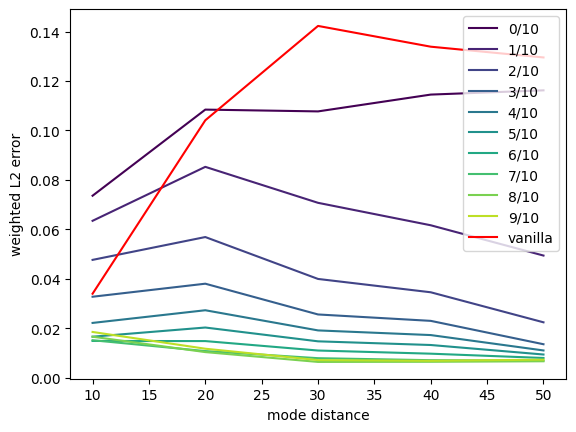

In [6]:
plt.figure()
for i in range(10):
	plt.plot(
		mode_dists,
		[np.mean(dist_temp_weighted_l2_errors[d][i]) for d in mode_dists],
		color = cm.get_cmap('viridis')(i/10),
		label = f'{i}/10'
	)
plt.plot(mode_dists, [np.mean(dist_weighted_l2_errors[d]) for d in mode_dists], color='r', label='vanilla')
plt.xlabel('mode distance')
plt.ylabel('weighted L2 error')
plt.legend()
plt.show()

/var/folders/d1/b543lnys7vj_9h29pnfhq49w0000gn/T/ipykernel_30935/335717201.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = cm.get_cmap('viridis')(i/10),


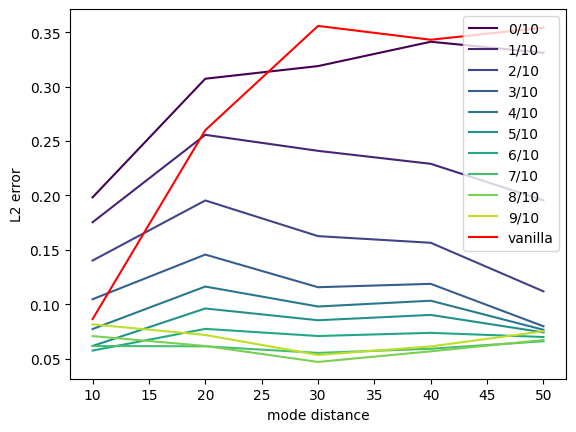

In [8]:

plt.figure()
for i in range(10):
	plt.plot(
		mode_dists,
		[np.mean(dist_temp_l2_errors[d][i]) for d in mode_dists],
		color = cm.get_cmap('viridis')(i/10),
		label = f'{i}/10'
	)
plt.plot(mode_dists, [np.mean(dist_l2_errors[d]) for d in mode_dists], color='r', label='vanilla')
plt.xlabel('mode distance')
plt.ylabel('L2 error')
plt.legend()
plt.show()

/var/folders/d1/b543lnys7vj_9h29pnfhq49w0000gn/T/ipykernel_30935/7261588.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = cm.get_cmap('viridis')(i/10),


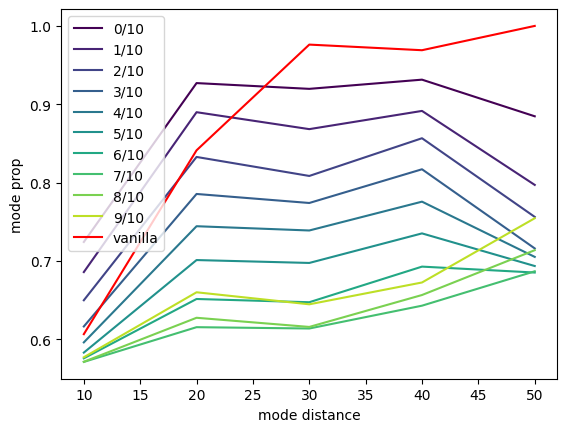

In [9]:
plt.figure()
for i in range(10):
	plt.plot(
		mode_dists,
		[np.mean(dist_temp_mode_prop[d][i]) for d in mode_dists],
		color = cm.get_cmap('viridis')(i/10),
		label = f'{i}/10'
	)
plt.plot(mode_dists, [np.mean(dist_mode_props[d]) for d in mode_dists], color='r', label='vanilla')
plt.xlabel('mode distance')
plt.ylabel('mode prop')
plt.legend()
plt.show()